In [2]:
import pandas as pd
import sys
sys.path.append('/home/azureuser/cloudfiles/code/Users/manhductranvu/reeval-multi/mirt-official') 
from load_params import load_and_rotate

resmat = pd.read_pickle("../data/resmat.pkl")

theta, a, b = load_and_rotate(rotation=None, model_path='../data/mirt_model_k2_rep0.pt')

# varimax, oblimax, quartimax, equamax, geomin_ort, promax, oblimin, quartimin, geomin_obl

# Step 1: Get the final theta tensor into a NumPy array
theta_abilities = theta
# Step 2: Create a labeled pandas DataFrame
# Use the model names from your original resmat for the index
model_names = resmat.index
factor_names = [f'F{i+1}' for i in range(theta.shape[1])]
ability_df = pd.DataFrame(theta_abilities, index=model_names, columns=factor_names)

--- Cache not found, computing rotation ---
--- Initial Loaded Data ---
Original theta shape: torch.Size([183, 2])
Original 'a' matrix shape: torch.Size([78712, 2])

--- No Rotation Applied ---
Using original 'a' matrix shape: (78712, 2)
Using original theta shape: (183, 2)

--- Saving to Cache ---
Cached results saved to output



/Users/ronan/Developer/reeval-multi/mirt-official/load_params.py:58: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_data = torch.load(model_path, map_location=torch.dev

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

sys.path.append('..') 
import style
plt.rcParams.update(style.rcparams)

a_df_scenarios = pd.DataFrame(a, index=resmat.columns.get_level_values('scenario'), columns=factor_names)
# Group by similar index values and calculate mean
a_df_grouped = a_df_scenarios.groupby(a_df_scenarios.index).mean().dropna()


/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_43936/81466236.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a_df_grouped = a_df_scenarios.groupby(a_df_scenarios.index).mean().dropna()


In [4]:
import sys
sys.path.append('.')
import pandas as pd

resmat = pd.read_pickle("../data/resmat.pkl")

# Extract names for labeling
item_names = resmat.columns.get_level_values('input.text').to_list()
model_names = resmat.index.to_list()

df_theta = pd.DataFrame(theta, index=model_names, columns=factor_names) + 5
df_a = pd.DataFrame(a, index=resmat.columns.get_level_values('scenario'), columns=factor_names)

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_43936/1073814106.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a_df_grouped = a_df_scenarios.groupby(a_df_scenarios.index).mean().dropna()


Original a_df shape: (78712, 2)
Grouped a_df shape: (22, 2)
Number of unique scenarios: 22


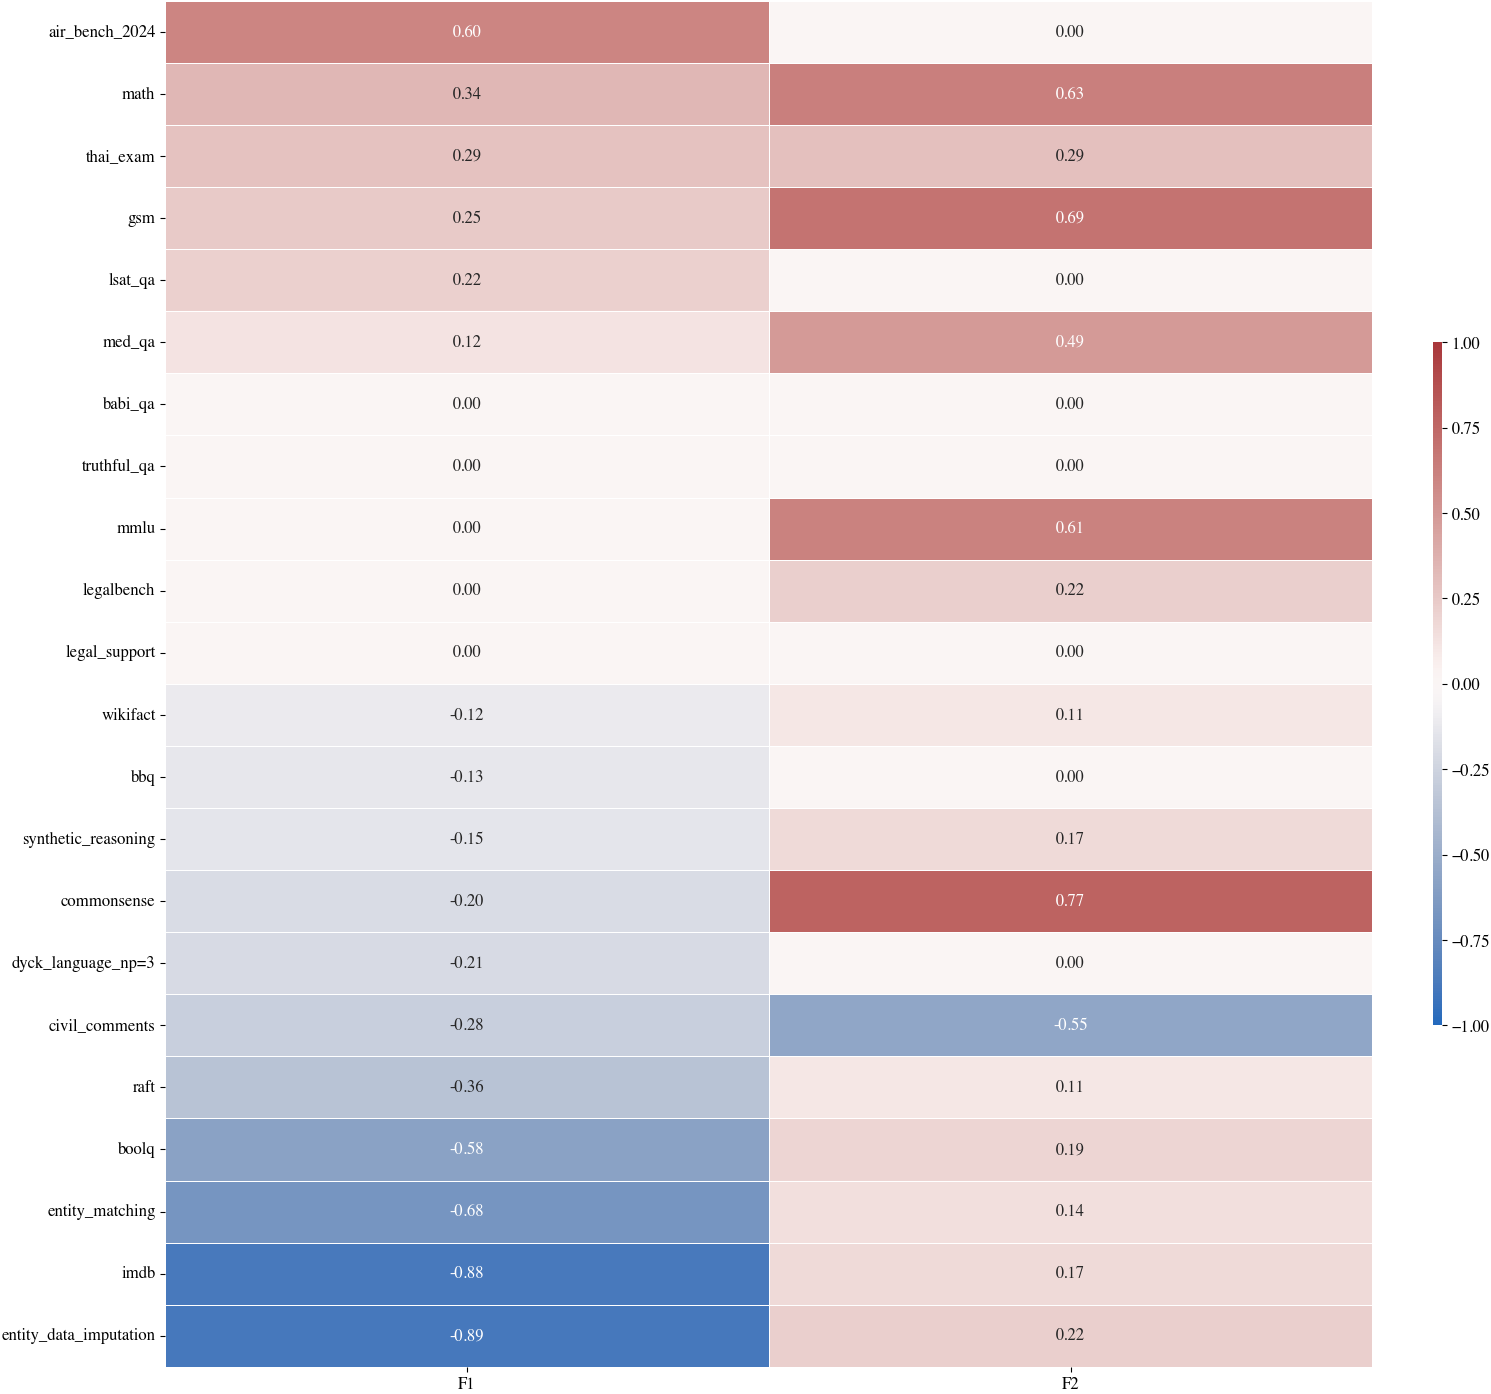

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


sys.path.append('..') 
import style
plt.rcParams.update(style.rcparams)

factor_names = [f'F{i+1}' for i in range(df_a.shape[1])]

a_df_scenarios = pd.DataFrame(df_a.values, index=resmat.columns.get_level_values('scenario'), columns=factor_names)
# Group by similar index values and calculate mean
a_df_grouped = a_df_scenarios.groupby(a_df_scenarios.index).mean().dropna()

# Check the resulting shape
print(f"Original a_df shape: {a_df_scenarios.shape}")
print(f"Grouped a_df shape: {a_df_grouped.shape}")
print(f"Number of unique scenarios: {len(a_df_grouped.index)}")

inspection = a_df_grouped.copy()
inspection[abs(inspection) < 0.1] = 0

# 1. Order rows by sum (scenarios with highest total loadings first) 
# row_sums = inspection.abs().sum(axis=1)
# row_order = row_sums.sort_values(ascending=False).index

# 2. Reorder inspection matrix - only reorder rows, keep columns in original order
# ordered_inspection = inspection.loc[row_order, :]
ordered_inspection = inspection.sort_values(by='F1', ascending=False)

# You can adjust figsize to make the plot larger or smaller for better readability.
fig, ax = plt.subplots(figsize=(15, 14))

# 2. Generate the clustered heatmap
# sns.heatmap is the core function here.
sns.heatmap(
    ordered_inspection,     # The clustered data to plot
    annot=True,       # Write the data value in each cell
    fmt=".2f",        # Use two decimal places for annotations
    cmap='vlag',  # Use the 'vlag' color map (blue-white-red)
    linewidths=.5,    # Add lines between cells
    ax=ax,
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={'shrink': 0.5, 'aspect': 75}
)

# 3. Add titles and labels for clarity
ax.set_xlabel('')
ax.set_ylabel('')

# 4. Ensure labels are not cut off
# plt.tight_layout()

# 5. Display the plot
plt.show()

# To save the figure to a file, uncomment the line below
fig.savefig('../result/clustered_heatmap_.pdf', bbox_inches='tight')

In [32]:
df_theta.sort_values(by='F2', ascending=False)

,F1,F2
openai/gpt-4o-2024-08-06,5.630698,9.711943
qwen/qwen2.5-72b-instruct-turbo,4.756757,9.549820
meta/llama-3.2-90b-vision-instruct-turbo,4.378191,9.508584
meta/llama-3.1-70b-instruct-turbo,3.567820,9.401593
deepseek-ai/deepseek-v3,3.887778,9.243055
...,...,...
tiiuae/falcon-7b,2.836783,1.169452
tiiuae/falcon-7b-instruct,2.684178,0.192080
together/glm,2.780387,0.023899
openai/text-babbage-001,3.266075,-0.786724


In [35]:
# 1. Count the NaN values for each row (test-taker)
nan_counts = resmat.isnull().sum(axis=1)

# 2. Sort the results to find the test-takers with the least NaNs
sorted_nan_counts = nan_counts.sort_values().head(100)

In [36]:
sorted_nan_counts

request.model
openai/gpt-3.5-turbo-0613                    2295
meta/llama-2-7b                              7280
mistralai/mistral-7b-v0.1                    7280
meta/llama-2-13b                             7280
meta/llama-2-70b                             7280
                                            ...  
openai/gpt-4-1106-preview                   60563
meta/llama-3.3-70b-instruct-turbo           60563
google/gemini-2.0-flash-exp                 60563
meta/llama-3.2-90b-vision-instruct-turbo    60563
mistralai/mixtral-8x7b-32kseqlen            60563
Length: 100, dtype: int64

In [37]:

from collections import defaultdict

# 1. Assume sorted_nan_counts Series exists from the code above

# 2. Initialize a defaultdict and loop through the Series
grouped_models_dd = defaultdict(list)

for model, count in sorted_nan_counts.items():
    grouped_models_dd[count].append(model)

# 3. Convert to a regular dict (optional) and print
grouped_models_dd = dict(grouped_models_dd)
print(grouped_models_dd)

{2295: ['openai/gpt-3.5-turbo-0613'], 7280: ['meta/llama-2-7b', 'mistralai/mistral-7b-v0.1', 'meta/llama-2-13b', 'meta/llama-2-70b'], 18765: ['AlephAlpha/luminous-extended', 'openai/text-davinci-002', 'openai/text-davinci-003', 'AlephAlpha/luminous-supreme', 'ai21/j2-grande', 'AlephAlpha/luminous-base', 'ai21/j2-jumbo'], 20444: ['openai/gpt-3.5-turbo-0301'], 20503: ['tiiuae/falcon-7b', 'meta/llama-65b', 'tiiuae/falcon-40b'], 23691: ['openai/text-curie-001', 'openai/text-ada-001', 'openai/text-babbage-001', 'cohere/medium-20221108', 'cohere/xlarge-20221108', 'ai21/j1-large', 'cohere/xlarge-20220609', 'ai21/j1-grande', 'ai21/j1-jumbo', 'openai/babbage', 'writer/palmyra-instruct-30', 'openai/curie', 'cohere/command-medium-beta', 'openai/ada', 'cohere/medium-20220720', 'ai21/j1-grande-v2-beta', 'openai/davinci', 'writer/palmyra-x', 'cohere/command-xlarge-beta'], 24226: ['ai21/j2-large'], 25429: ['mosaicml/mpt-30b', 'lmsys/vicuna-13b-v1.3', 'stanford/alpaca-7b', 'together/redpajama-incite-i

In [38]:
# --- Step 3: Iterate, filter, sort, and print ---
# Loop through each group of models from the grouped_models dictionary
for nan_count, model_list in grouped_models_dd.items():
    print(f"--- Group with {nan_count} NaN values ---")

    # Find which models from the list actually exist in df_theta's index
    # This prevents errors if a model is not in the DataFrame
    existing_models_in_group = [model for model in model_list if model in df_theta.index]

    if not existing_models_in_group:
        print("None of the models in this group were found in df_theta.\n")
        continue

    # Select the rows for the existing models
    subset_df = df_theta.loc[existing_models_in_group]

    # Sort the resulting subset by 'F1' in descending order
    sorted_subset = subset_df.sort_values(by='F1', ascending=False)

    # Print the sorted group
    print(sorted_subset)
    print("\n" + "="*40 + "\n") # Separator for readability

--- Group with 2295 NaN values ---
                                 F1        F2
openai/gpt-3.5-turbo-0613  2.856516  6.442135


--- Group with 7280 NaN values ---
                                 F1        F2
meta/llama-2-13b           3.343313  5.882162
meta/llama-2-7b            2.115500  2.841147
meta/llama-2-70b           1.245383  6.924807
mistralai/mistral-7b-v0.1  1.049376  6.536769


--- Group with 18765 NaN values ---
                                    F1        F2
AlephAlpha/luminous-base      4.823655  6.351161
AlephAlpha/luminous-extended  3.720566  3.609069
AlephAlpha/luminous-supreme   3.488671  4.680024
ai21/j2-jumbo                 3.072772  6.344597
openai/text-davinci-003       1.654500  5.729459
ai21/j2-grande                1.561383  2.291110
openai/text-davinci-002       1.369188  5.781340


--- Group with 20444 NaN values ---
                                 F1        F2
openai/gpt-3.5-turbo-0301  3.365032  6.220149


--- Group with 20503 NaN values ---
        

In [18]:
import pandas as pd

# Standardize residuals (F2...F19), keep F1 as-is
theta_std = df_theta.copy()
for col in df_theta.columns[1:]:  # skip F1
    theta_std[col] = (df_theta[col] - df_theta[col].mean()) / df_theta[col].std()

# Build composite scores: F1 + standardized Fj
scores = {}
scores['score_1'] = pd.Series(df_theta['F1'], index=resmat.index)

for j in range(2, df_theta.shape[1] + 1):  # F2 to F19
    scores[f'score_{j}'] = pd.Series(
        df_theta['F1'] + theta_std[f'F{j}'],
        index=resmat.index
    )

# Convert to DataFrame if you want a single table
scores_df = pd.DataFrame(scores)


/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_43936/3445424401.py:192: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


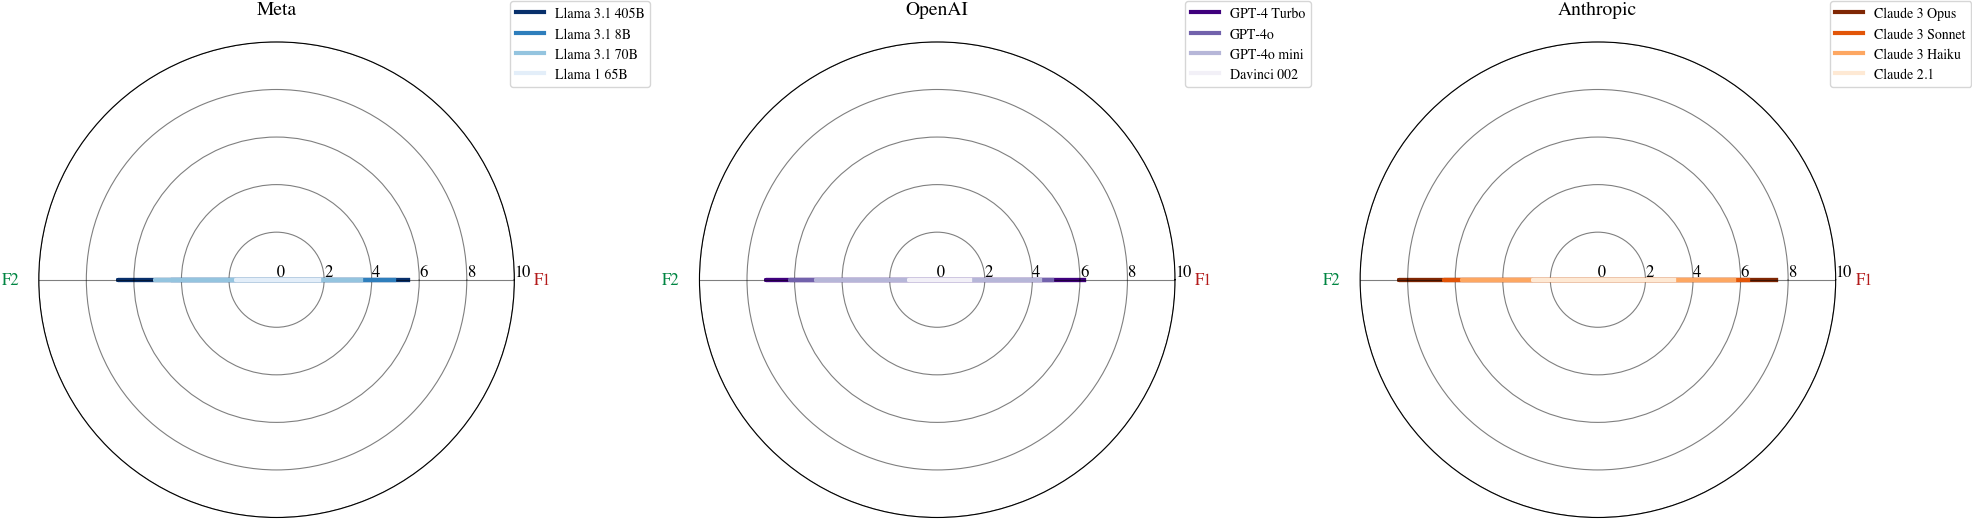

Selected models for radar charts:

META:
  Llama 3.1 405B
  Llama 3.1 8B
  Llama 3.1 70B
  Llama 1 65B

OPENAI:
  GPT-4 Turbo
  GPT-4o
  GPT-4o mini
  Davinci 002

ANTHROPIC:
  Claude 3 Opus
  Claude 3 Sonnet
  Claude 3 Haiku
  Claude 2.1


In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from math import pi
import sys
sys.path.append('..')
import style
plt.rcParams.update(style.rcparams)

common_indices = [
    'anthropic/claude-3-sonnet-20240229', 'anthropic/claude-3-opus-20240229', 'anthropic/claude-3-haiku-20240307', 'anthropic/stanford-online-all-v4-s3',
    'meta/llama-3.1-8b-instruct-turbo', 'meta/llama-3.1-70b-instruct-turbo', 'meta/llama-3.1-405b-instruct-turbo', 'meta/llama-65b',
    'openai/gpt-4o-2024-05-13', 'openai/gpt-4o-mini-2024-07-18', 'openai/gpt-4-turbo-2024-04-09', 'openai/text-davinci-002'
]

# EDIT: Added a mapping from code names to formal display names
model_name_mapping = {
    'anthropic/claude-3-sonnet-20240229': 'Claude 3 Sonnet',
    'anthropic/claude-3-opus-20240229': 'Claude 3 Opus',
    'anthropic/claude-3-haiku-20240307': 'Claude 3 Haiku',
    'anthropic/stanford-online-all-v4-s3': 'Claude 2.1',
    'meta/llama-3.1-8b-instruct-turbo': 'Llama 3.1 8B',
    'meta/llama-3.1-70b-instruct-turbo': 'Llama 3.1 70B',
    'meta/llama-3.1-405b-instruct-turbo': 'Llama 3.1 405B',
    'meta/llama-65b': 'Llama 1 65B',
    'openai/gpt-4o-2024-05-13': 'GPT-4o',
    'openai/gpt-4o-mini-2024-07-18': 'GPT-4o mini',
    'openai/gpt-4-turbo-2024-04-09': 'GPT-4 Turbo',
    'openai/text-davinci-002': 'Davinci 002'
}


scores_mapping = {
    'F1': scores['score_1'],
    'F2': scores['score_2'],
}

skill_scores = pd.DataFrame(scores_mapping)

# Psychometric Groupings of AI Capability Dimensions

reasoning = {
    'F1': ('Abstract Reasoning', 'F1'),
    # 'F6': ('Abstract Reasoning', 'F6'),
    # 'F11': ('General Problem Solving', 'F11'),
    # 'F12': ('Procedural and Generative Planning', 'F12'),
    # 'F17': ('Complex Reasoning', 'F17'),
    # 'F18': ('Application of External Knowledge', 'F18'),
    # 'F19': ('Formal Reasoning and Procedural Adherence', 'F19')
}

comprehension = {
    'F2': ('In-Context Retrieval', 'F2'),
    # 'F13': ('In-Context Analysis', 'F13'),
    # 'F4': ('Literal Reading Comprehension', 'F4'),
    # 'F5': ('Procedural Comprehension', 'F5'),
    # 'F10': ('Descriptive Comprehension', 'F10'),
    # 'F7': ('Dense and Formal Language Comprehension', 'F7'),
    # 'F8': ('Internal Knowledge and Application', 'F8'),
    # 'F15': ('General Verbal Comprehension', 'F15'),
    # 'F9': ('Verbal Fluency', 'F9'),
    # 'F16': ('Informal Language Comprehension', 'F16')
}

style = {
    # 'F3': ('Safet and Ethics Alignment', 'SEA'),
    # 'F14': ('Expansive Discourse', 'ED')
}

# --- START OF CHANGE 1: Define colors and map skills to groups ---

# 1. Define a color for each capability group
group_colors = {
    "Reasoning": '#B31B1B',
    "Comprehension": '#008542',
    "Style": '#0033A0'
}

# 2. Create a reverse map from a skill ('F2') to its group name
skill_to_group_map = {}
for group_name, skills_dict in {
    "Reasoning": reasoning,
    "Comprehension": comprehension,
    "Style": style
}.items():
    for skill_code in skills_dict:
        skill_to_group_map[skill_code] = group_name



all_capability_dims = {
    **reasoning,
    **comprehension,
    **style
}

skill_scores = skill_scores[list(all_capability_dims.keys())]
abbreviated_labels = [all_capability_dims[col][1] for col in skill_scores.columns]


# 3. Create a list of colors that matches the order of the labels
label_colors = [group_colors[skill_to_group_map[col]] for col in skill_scores.columns]


skill_scores = skill_scores.loc[common_indices]


# 4. Update the function to accept and apply label colors
def create_radar_chart(data, labels, title, ax, colors=None, model_names=None, label_colors=None):
    N = len(labels)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    if colors is None:
        colors = plt.cm.tab10(np.linspace(0, 1, len(data)))
    for i, (model_data, color) in enumerate(zip(data, colors)):
        values = model_data.tolist()
        values += values[:1]
        model_name = model_names[i] if model_names else f'Model {i+1}'
        display_name = model_name.split('/')[-1] if '/' in model_name else model_name
        ax.plot(angles, values, '-', linewidth=3, label=display_name, color=color, alpha=1, zorder=i + 1)
        ax.fill(angles, values, color=color, alpha=0.35)
    ax.tick_params(pad=10)
    range_ax = range(0, 11, 2)
    ax.set_ylim(range_ax[0], range_ax[-1])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=12, weight='bold')
    
    # This is the new part: Apply the colors to the tick labels
    if label_colors:
        for xtick, color in zip(ax.get_xticklabels(), label_colors):
            xtick.set_color(color)
            
    ax.grid(True, alpha=0.5, color='black')
    ax.set_rgrids(range_ax, angle=0, labels=range_ax, fontsize=12)
    ax.set_rmin(range_ax[0])



companies = { 'meta': [], 'openai': [], 'anthropic': [] }
common_models = skill_scores.dropna().index
for model in common_models:
    if model.startswith('meta/'): companies['meta'].append(model)
    elif model.startswith('openai/'): companies['openai'].append(model)
    elif model.startswith('anthropic/'): companies['anthropic'].append(model)

def select_top_models(models, n=6, explicit_models=None):
    if not models: return []
    result = []
    if explicit_models:
        result = [model for model in explicit_models if model in models]
    if len(result) >= n: return result[:n]
    model_scores = skill_scores.loc[models].mean(axis=1).sort_values(ascending=False)
    remaining_slots = n - len(result)
    for model in model_scores.index:
        if model not in result:
            result.append(model)
            remaining_slots -= 1
            if remaining_slots == 0: break
    return result

selected_models = {
    company: select_top_models(models, n=6) for company, models in companies.items()
}

fig, axes = plt.subplots(1, 3, figsize=(20, 12), subplot_kw=dict(projection='polar'))
axes = axes.flatten()

company_names = ['Meta', 'OpenAI', 'Anthropic']
company_keys = ['meta', 'openai', 'anthropic']

for i, (company_key, company_name) in enumerate(zip(company_keys, company_names)):
    models = selected_models[company_key]
    if models:
        model_data = skill_scores.loc[models].values
        display_names = [model_name_mapping.get(model, model) for model in models]
        if company_key == 'meta':
            colors = plt.cm.Blues_r(np.linspace(0, 0.9, len(models)))
        elif company_key == 'openai':
            colors = plt.cm.Purples_r(np.linspace(0, 0.9, len(models)))
        elif company_key == 'anthropic':
            colors = plt.cm.Oranges_r(np.linspace(0, 0.9, len(models)))
        
        create_radar_chart(model_data, abbreviated_labels, company_name, axes[i],
                           colors=colors, model_names=display_names, label_colors=label_colors)
        
        axes[i].set_title(company_name, size=14, weight='bold', pad=20)
        axes[i].legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
    else:
        axes[i].text(0.5, 0.5, f'No {company_name} models found', transform=axes[i].transAxes, ha='center', va='center')
        axes[i].set_title(company_name, size=14, weight='bold', pad=20)

plt.tight_layout()
plt.savefig('../result/model_families_all_skill_radar_charts.pdf', bbox_inches='tight')
plt.show()

print("Selected models for radar charts:")
for company, models in selected_models.items():
    print(f"\n{company.upper()}:")
    for model in models:
        formal_name = model_name_mapping.get(model, model)
        print(f"  {formal_name}")